In [ ]:
tensorboard --logdir=/mnt/g/train_data/checkpoints0303/AUGAN_MVP_01 --port=6006

✅ 提取到物理间距: Z=0.0360, X=0.2000, Y=0.2000
🎉 真实比例三视图已生成！请查看 check_views_spacing.png。


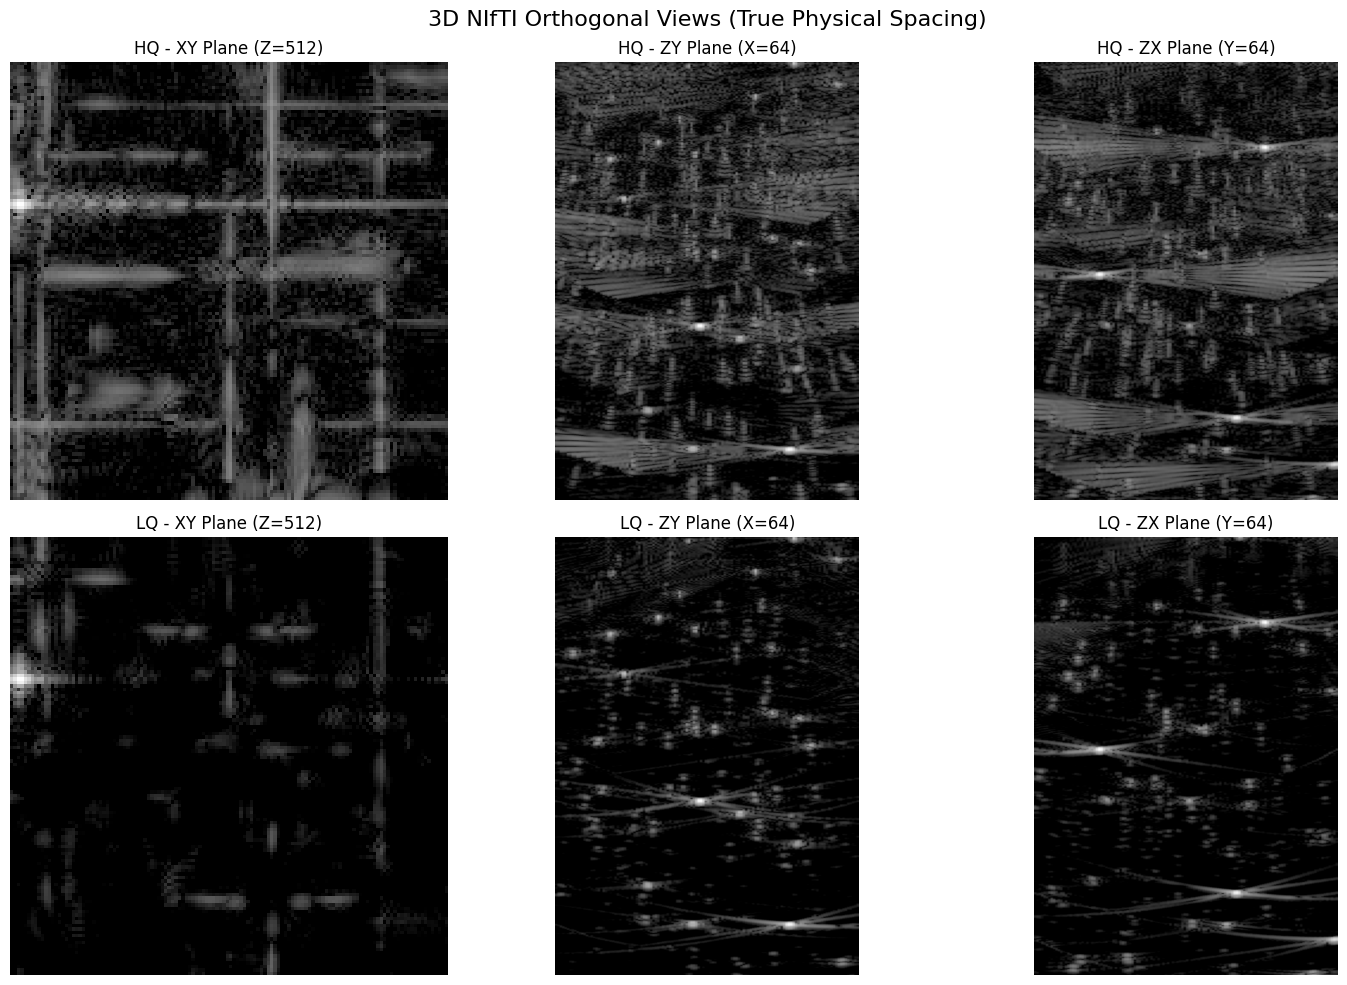

In [6]:
import nibabel as nib
import matplotlib.pyplot as plt

# 随便挑一个配对的 001 样本
hq_file = "/home/liujia/g_linux/Simu_Data/Recon_HQ_33/SimData_NII_0001_Pts_282_hq_33ang_dB.nii"
lq_file = "/home/liujia/g_linux/Simu_Data/Recon_SQ_75/SimData_NII_0001_Pts_282_sq_75ang_dB.nii"

# 读取 NIfTI 文件对象
hq_img = nib.load(hq_file)
lq_img = nib.load(lq_file)

hq_data = hq_img.get_fdata()
lq_data = lq_img.get_fdata()

# ==========================================
# 2. 自动获取体素间距并计算显示比例 (Aspect Ratio)
# ==========================================
# 获取物理间距，例如 (0.0362, 0.2, 0.2)
dz, dx, dy = hq_img.header.get_zooms()[:3] 

print(f"✅ 提取到物理间距: Z={dz:.4f}, X={dx:.4f}, Y={dy:.4f}")

# 计算 imshow 需要的像素高宽比
# aspect = 纵轴间距 / 横轴间距
aspect_xy = dx / dy  # X-Y平面 (通常是 0.2/0.2 = 1.0，正方形)
aspect_zy = dz / dy  # Z-Y平面 (0.0362/0.2 = 0.181，像素会被压扁还原真实比例)
aspect_zx = dz / dx  # Z-X平面 (0.0362/0.2 = 0.181)

# ==========================================
# 3. 提取正中间切片
# ==========================================
z_mid, x_mid, y_mid = hq_data.shape[0]//2, hq_data.shape[1]//2, hq_data.shape[2]//2

def get_3_views(data):
    view_xy = data[z_mid, :, :] # 看 X-Y 平面
    view_zy = data[:, x_mid, :] # 看 Z-Y 平面
    view_zx = data[:, :, y_mid] # 看 Z-X 平面
    return view_xy, view_zy, view_zx

hq_xy, hq_zy, hq_zx = get_3_views(hq_data)
lq_xy, lq_zy, lq_zx = get_3_views(lq_data)

# ==========================================
# 4. 开始带比例画图
# ==========================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("3D NIfTI Orthogonal Views (True Physical Spacing)", fontsize=16)

# 第一排：HQ (Truth)
axes[0, 0].imshow(hq_xy, cmap='gray', aspect=aspect_xy)
axes[0, 0].set_title(f"HQ - XY Plane (Z={z_mid})")

axes[0, 1].imshow(hq_zy, cmap='gray', aspect=aspect_zy)
axes[0, 1].set_title(f"HQ - ZY Plane (X={x_mid})")

axes[0, 2].imshow(hq_zx, cmap='gray', aspect=aspect_zx)
axes[0, 2].set_title(f"HQ - ZX Plane (Y={y_mid})")

# 第二排：LQ (Input)
axes[1, 0].imshow(lq_xy, cmap='gray', aspect=aspect_xy)
axes[1, 0].set_title(f"LQ - XY Plane (Z={z_mid})")

axes[1, 1].imshow(lq_zy, cmap='gray', aspect=aspect_zy)
axes[1, 1].set_title(f"LQ - ZY Plane (X={x_mid})")

axes[1, 2].imshow(lq_zx, cmap='gray', aspect=aspect_zx)
axes[1, 2].set_title(f"LQ - ZX Plane (Y={y_mid})")

for ax in axes.flatten():
    ax.axis('off')

plt.tight_layout()
output_img = "check_views_spacing.png"
plt.savefig(output_img, dpi=150, bbox_inches='tight')
print(f"🎉 真实比例三视图已生成！请查看 {output_img}。")